# Практическая работа 2: "Работа с табличными данными"


**Задание 1**. Подключение библиотек


<p>При выполнении практической работы будут использоваться следующие библиотеки:</p>
<table>
    <tr>
        <th>Библиотека</th>
        <th>Назначение</th>
    </tr>
    <tr>
        <td><a href="https://pandas.pydata.org/docs/">Pandas</a></td>
    </tr>
    <tr>
        <td><a href="https://numpy.org/doc/">Numpy</a></td>
    </tr>
    <tr>
        <td><a href="https://matplotlib.org/stable/index.html">Matplotlib</a></td>
    </tr>
    
</table>
Заполните колонку "Назначение" в таблице и ниже подключите библиотеки для работы.

In [1]:
#ВАШ КОД (для подключения библиотек)

import pandas as pd # Работа с таблицами
import numpy as np # Математика и рачёты

import matplotlib as mpl # Визуализация данных

**Задание 2**. Интеграция данных

***Интеграция данных*** - это процесс объединения данных их нескольких источников в единый набор данных (датасет). Объединение можно выполнить как *вертикально* (обычное склеивание), так и *горизонтальное* (аналог *join*() по ключу).

Создайте **2 набора данных** и выполните *вертикальное* склеивание, используя функцию *concat*().

Ответьте на следующие вопросы:
1.   Как создать набор данных?
2.   Какие параметры принимает функция *concat*()?


In [2]:
#ВАШ КОД

# Первый набор данных
df1 = pd.DataFrame({
    'Name': ['Артём', 'Давид'],
    'Age': [18, 23]
})

# Второй набор данных
df2 = pd.DataFrame({
    'Name': ['Charlie', 'David'],
    'Age': [35, 40]
})

result = pd.concat([df1, df2])

print(result)

      Name  Age
0    Артём   18
1    Давид   23
0  Charlie   35
1    David   40


Ответы на вопросы:

1. Набор данных создаётся с помощью функции pd.DataFrame(), в которую передаются данные в виде словаря, где ключи это названия столбцов, а значения это списки данных.

2. Основные параметры функции concat():

    objs - список объединяемых объектов (DataFrame или Series)

    axis - ось объединения (0 вертикально, 1 горизонтально)

    ignore_index - переиндексация строк

    join - способ объединения (inner или outer)

Создайте **2 набора данных** и выполните *горизонтальное* склеивание, используя функцию merge().

Ответьте на следующие вопросы:
1. В чем разница между *concat*() и *merge*()?
2. Какие параметры принимает функция *merge*()?
3. Выполните *left*, *right*, *inner*, *outher* склеивание и сделайте выводы, относительно разницы полученных результатов.

In [3]:
#ВАШ КОД

df1 = pd.DataFrame({
    'ID': [1, 2, 3, 4],
    'Name': ['Alice', 'Иван', 'Charlie', 'Аркадий']
})

df2 = pd.DataFrame({
    'ID': [2, 3, 4, 5],
    'Salary': [50000, 60000, 70000, 80000]
})

merged_inner = pd.merge(df1, df2, on='ID')
print("Горизонтальное объединение (merge)\n", merged_inner)

print("\nВсе типы соединений\n")
inner = pd.merge(df1, df2, on='ID', how='inner')
print("ВINNER (пересечение)\n", inner)

outer = pd.merge(df1, df2, on='ID', how='outer')
print("OUTER (полное объединение)\n", outer)

left = pd.merge(df1, df2, on='ID', how='left')
print("LEFT (левое соединение)\n", left)

right = pd.merge(df1, df2, on='ID', how='right')
print("RIGHT (правое соединение)\n", right)

Горизонтальное объединение (merge)
    ID     Name  Salary
0   2     Иван   50000
1   3  Charlie   60000
2   4  Аркадий   70000

Все типы соединений

ВINNER (пересечение)
    ID     Name  Salary
0   2     Иван   50000
1   3  Charlie   60000
2   4  Аркадий   70000
OUTER (полное объединение)
    ID     Name   Salary
0   1    Alice      NaN
1   2     Иван  50000.0
2   3  Charlie  60000.0
3   4  Аркадий  70000.0
4   5      NaN  80000.0
LEFT (левое соединение)
    ID     Name   Salary
0   1    Alice      NaN
1   2     Иван  50000.0
2   3  Charlie  60000.0
3   4  Аркадий  70000.0
RIGHT (правое соединение)
    ID     Name  Salary
0   2     Иван   50000
1   3  Charlie   60000
2   4  Аркадий   70000
3   5      NaN   80000


Ответы на вопросы:

1. Разница между concat() и merge():

concat() используется для склеивания таблиц по оси (по строкам или столбцам), а merge() используется для объединения таблиц по общему ключу (аналог SQL JOIN).

2. Основные параметры функции merge():

    left, right - объединяемые таблицы

    on - общий столбец (ключ)

    how - тип соединения (inner, left, right, outer)

    left_on, right_on - если ключи называются по-разному

    suffixes - суффиксы для одинаковых столбцов

3. Вывод по типам объединения:

    INNER - только совпадающие строки

    LEFT - все строки из левой таблицы, + совпадения из правой

    RIGHT - все строки из правой таблицы

    OUTER - все строки из обеих таблиц

**Задание 3**. Оценка объема данных

***Оценка объема данных*** необходима для определения сложности решаемой задачи и достаточности данных для ее решения. Оценка объема позволяет определить не только количество данных, но также и количество атрибутов.
1. Загрузите датасет *parkinson_disease.csv* из курса.
2. При помощи методов *shape*(), *size*() и *info*() изучите набор данных:    

*   какие атрибуты и какого типа представлены,
*   размер набора данных,
*   количество строк и колонок,
*   есть ли пропущенные строки и т.д.
3. Сделать выводы относительно качества исходных данных.

In [4]:
#ВАШ КОД

df = pd.read_csv('../../parkinson_disease.csv')

print("\nВернёт: (количество_строк, количество_столбцов)\n", df.shape)

print("\nПо формуле: rows * columns\n", df.size)

print("\nПоказывает: (названия столбцов, типы данных (int, float, object), количество НЕ пустых значений и есть ли пропуски)")
df.info()


Вернёт: (количество_строк, количество_столбцов)
 (756, 755)

По формуле: rows * columns
 570780

Показывает: (названия столбцов, типы данных (int, float, object), количество НЕ пустых значений и есть ли пропуски)
<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


Выводы: 

1. В датасете представлены числовые атрибуты типов float64 и int64.

2. Размер набора данных составляет 570780 элементов.

3. Набор данных содержит 756 строк и 755 столбцов.

4. Пропущенные значения отсутствуют.

**Задание 4**. Преобразование и очистка данных

4.1. Определить количество ***уникальных значений*** в каждом столбце. Оценить возможность преобразования данных в числовые значения.

In [ ]:
#ВАШ КОД

df.nunique()    #one-hot кодирование (марки машин) почиать: тогда это будут категориальные признаки

#Каждое название марки становится отдельной колонкой.
#brand_BMW: [1, 0, 1]
#brand_Audi: [0, 1, 0]

id                           252
gender                         2
PPE                          740
DFA                          745
RPDE                         748
                            ... 
tqwt_kurtosisValue_dec_33    752
tqwt_kurtosisValue_dec_34    753
tqwt_kurtosisValue_dec_35    753
tqwt_kurtosisValue_dec_36    754
class                          2
Length: 755, dtype: int64

Большинство признаков имеют большое количество уникальных значений и являются числовыми. Признаки gender и class имеют по 2 значения, но уже представлены в числовом виде, поэтому преобразование не требуется.

4.2. Получите информацию ***по атрибутам***: количество, средние значения, отклонения, квартили.

Сделать выводы по полученным данным.

In [6]:
#ВАШ КОД

stats = df.describe()
print(stats)

               id      gender         PPE         DFA        RPDE   numPulses  \
count  756.000000  756.000000  756.000000  756.000000  756.000000  756.000000   
mean   125.500000    0.515873    0.746284    0.700414    0.489058  323.972222   
std     72.793721    0.500079    0.169294    0.069718    0.137442   99.219059   
min      0.000000    0.000000    0.041551    0.543500    0.154300    2.000000   
25%     62.750000    0.000000    0.762833    0.647053    0.386537  251.000000   
50%    125.500000    1.000000    0.809655    0.700525    0.484355  317.000000   
75%    188.250000    1.000000    0.834315    0.754985    0.586515  384.250000   
max    251.000000    1.000000    0.907660    0.852640    0.871230  907.000000   

       numPeriodsPulses  meanPeriodPulses  stdDevPeriodPulses  locPctJitter  \
count        756.000000        756.000000          756.000000    756.000000   
mean         322.678571          0.006360            0.000383      0.002324   
std           99.402499          

Выводы: Набор данных содержит 756 строк и 755 столбцов, всего 570780 элементов. Все атрибуты представлены числовыми типами данных, пропущенные значения отсутствуют.

4.3. Преобразуйте ***категориальные*** признаки, предварительно проверив возможность этого преобразования.

In [7]:
#ВАШ КОД

df.select_dtypes(include='object')

""
0
1
2
3
4
...
751
752
753
754


Категориальные признаки отсутствуют, все данные уже числовые.

4.4. Проверить набор данных ***на дубликаты***

Если в наборе данных встречается дублирование, то можно, например, выполнить склеивание строк с одинаковым значением, расcчитав среднее по каждому из атрибутов.

In [8]:
#ВАШ КОД

duplicates_count = df.duplicated().sum()
print("Количество полных дубликатов:", duplicates_count)

Количество полных дубликатов: 1


**Задание 5**. Матрица корреляции

5.1. Постройте *матрицу корреляции* для **всех** признаков и сделайте выводы.


In [9]:
#ВАШ КОД

corr_martix = df.corr()
print(corr_martix.iloc[:5, :5])

              id    gender       PPE       DFA      RPDE
id      1.000000 -0.133605  0.026667  0.041938 -0.084606
gender -0.133605  1.000000  0.010175  0.099356  0.168321
PPE     0.026667  0.010175  1.000000 -0.094775 -0.405558
DFA     0.041938  0.099356 -0.094775  1.000000  0.155075
RPDE   -0.084606  0.168321 -0.405558  0.155075  1.000000


Выводы: Между большинством признаков наблюдается слабая корреляция (близкая к 0), что говорит об их независимости. Наиболее заметная зависимость наблюдается между PPE и RPDE (отрицательная корреляция), однако в целом сильных взаимосвязей между признаками нет.

5.2. Используя *corr*(), удалим сильнокоррелирующие признаки, корреляция которых превосходит 0,7. Определим, текущий размер датасета.

In [10]:
#ВАШ КОД

# 1. Вычисляем матрицу корреляций (по модулю, так как отрицательная корреляция тоже важна)
corr_matrix = df.corr().abs()

# 2. Выбираем верхний треугольник матрицы (чтобы не дублировать пары и не удалять столбец сам с собой)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Находим индексы колонок с корреляцией выше 0.7
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]

# 4. Удаляем эти колонки из датасета
df_reduced = df.drop(columns=to_drop)

# 5. Определяем текущий размер
print(f"Удалено признаков: {len(to_drop)}")
print(f"Новый размер датасета: {df_reduced.shape}")


Удалено признаков: 526
Новый размер датасета: (756, 229)


5.3. *Уменьшим количество признаков*, используя методику **хи-квадрат** Пирсона, и оставим только те, которые оказывают наибольшее влияние.

Для этого необходимо:
1. Удалить результирующую колонку.
2. Нормализовать значения в диапазоне от 0 до 1.
3. Применить хи-квадрат для выбора $n$ и более признаков (в качестве учебной задачи можем взять **10** признаков).
4. Извлечь 10 признаков и соединить их с результирующей колонкой.

In [12]:
#ВАШ КОД

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2

# Разделяем признаки и целевую переменную
X = df.drop('class', axis=1)
y = df['class']

# Нормализация (обязательно для chi2)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Применяем chi2
chi_scores = chi2(X_scaled, y)

# Создаём DataFrame с результатами
scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': chi_scores[0]
})

# Берём топ-10 признаков
top_features = scores.sort_values(by='Score', ascending=False).head(10)['Feature']

# Новый датасет
df_top = df[top_features]
df_top['class'] = y

df_top.head()

,tqwt_kurtosisValue_dec_26,tqwt_kurtosisValue_dec_27,tqwt_entropy_shannon_dec_11,tqwt_energy_dec_12,tqwt_entropy_shannon_dec_16,tqwt_stdValue_dec_11,tqwt_entropy_shannon_dec_15,tqwt_kurtosisValue_dec_28,tqwt_TKEO_std_dec_12,tqwt_kurtosisValue_dec_36,class
0,1.6058,1.5466,4.8840,0.000239,189.5000,0.005199,174.6920,1.5620,0.000059,18.9405,1
1,1.5772,1.5530,4.8483,0.000297,163.4516,0.005221,140.8136,1.5589,0.000169,45.1780,1
2,1.5921,1.5399,1.9849,0.000248,101.5144,0.003136,84.8129,1.5643,0.000021,4.7666,1
3,1.8829,6.9761,3.2053,0.000703,646.9783,0.004537,572.9586,3.7805,0.000493,4.0603,1
4,1.8821,7.8832,2.7170,0.000648,683.1305,0.003931,647.2537,6.1727,0.000328,6.1164,1


5.4. Постройте ***матрицу корреляции*** для **10** признаков и сделайте выводы.


In [ ]:
#ВАШ КОД

corr_top = df_top.corr()    #Что значит корреляция 1, 0 -1:  1 - сильно коррелирует, 0 - вообще не коррелирует, -1 - отрицательная корреляция
print(corr_top)

                             tqwt_kurtosisValue_dec_26  \
tqwt_kurtosisValue_dec_26                     1.000000   
tqwt_kurtosisValue_dec_27                     0.741218   
tqwt_entropy_shannon_dec_11                   0.199991   
tqwt_energy_dec_12                            0.243628   
tqwt_entropy_shannon_dec_16                   0.321652   
tqwt_stdValue_dec_11                          0.214649   
tqwt_entropy_shannon_dec_15                   0.296280   
tqwt_kurtosisValue_dec_28                     0.453748   
tqwt_TKEO_std_dec_12                          0.249425   
tqwt_kurtosisValue_dec_36                    -0.085546   
class                                        -0.335430   

                             tqwt_kurtosisValue_dec_27  \
tqwt_kurtosisValue_dec_26                     0.741218   
tqwt_kurtosisValue_dec_27                     1.000000   
tqwt_entropy_shannon_dec_11                   0.204447   
tqwt_energy_dec_12                            0.219847   
tqwt_entropy_

Выводы: Между отобранными признаками наблюдается различная степень корреляции, однако сильных зависимостей между большинством из них нет, что говорит об их относительной независимости.

(*) 5.5. Постройте ***тепловую матрицу корреляции*** и сделайте выводы.

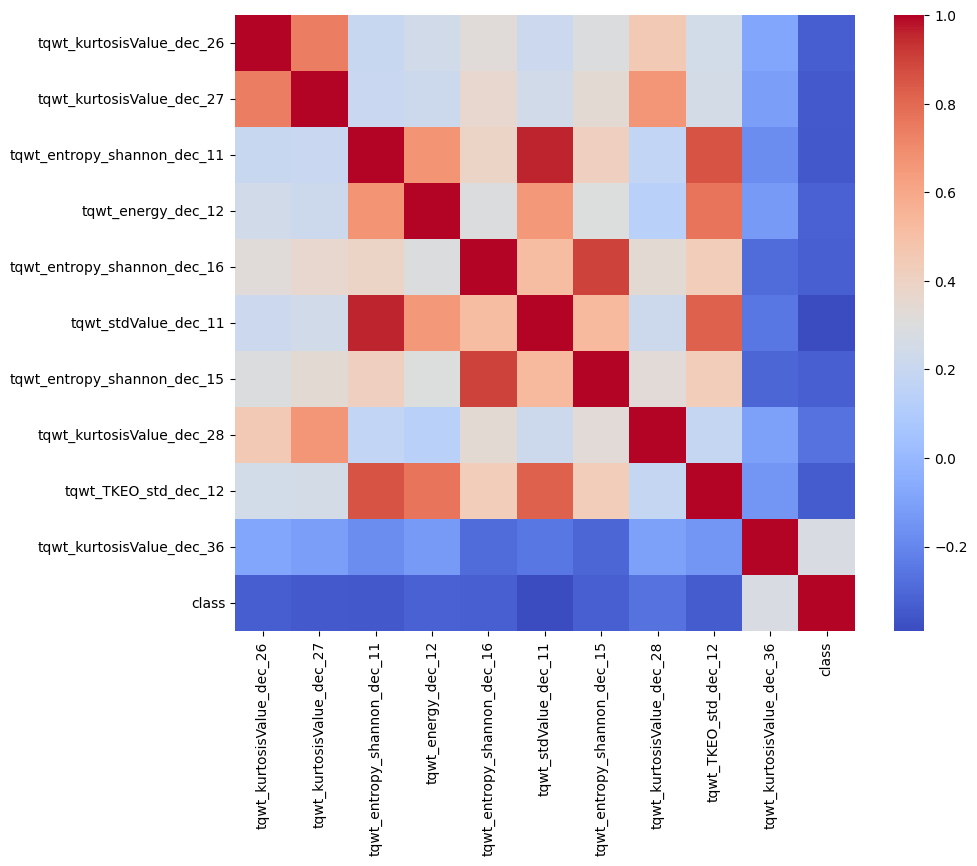

In [15]:
#ВАШ КОД

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, annot=False, cmap='coolwarm')
plt.show()

Выводы: Тепловая карта подтверждает, что между признаками отсутствуют сильные корреляции, что снижает риск мультиколлинеарности и делает выбранные признаки подходящими для дальнейшего анализа.

**Задание 6**. Визуализация данных

Для удобства визуализации данных можно реализовать единую функцию *visualize_dataset_attributes()* или выполнить перечисленные ниже построения для каждого признака в отдельности.

6.1. Построить *boxplot()* для **10** наиболее значивых признаков, выделенных ранее. Проанализируйте графики и сделайте выводы.

Пример оформления (для одного признака)
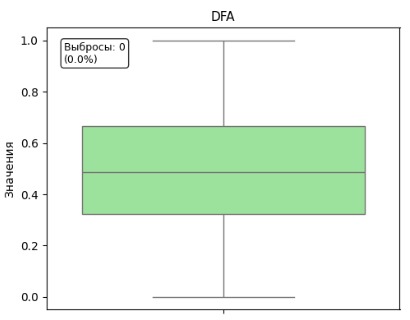

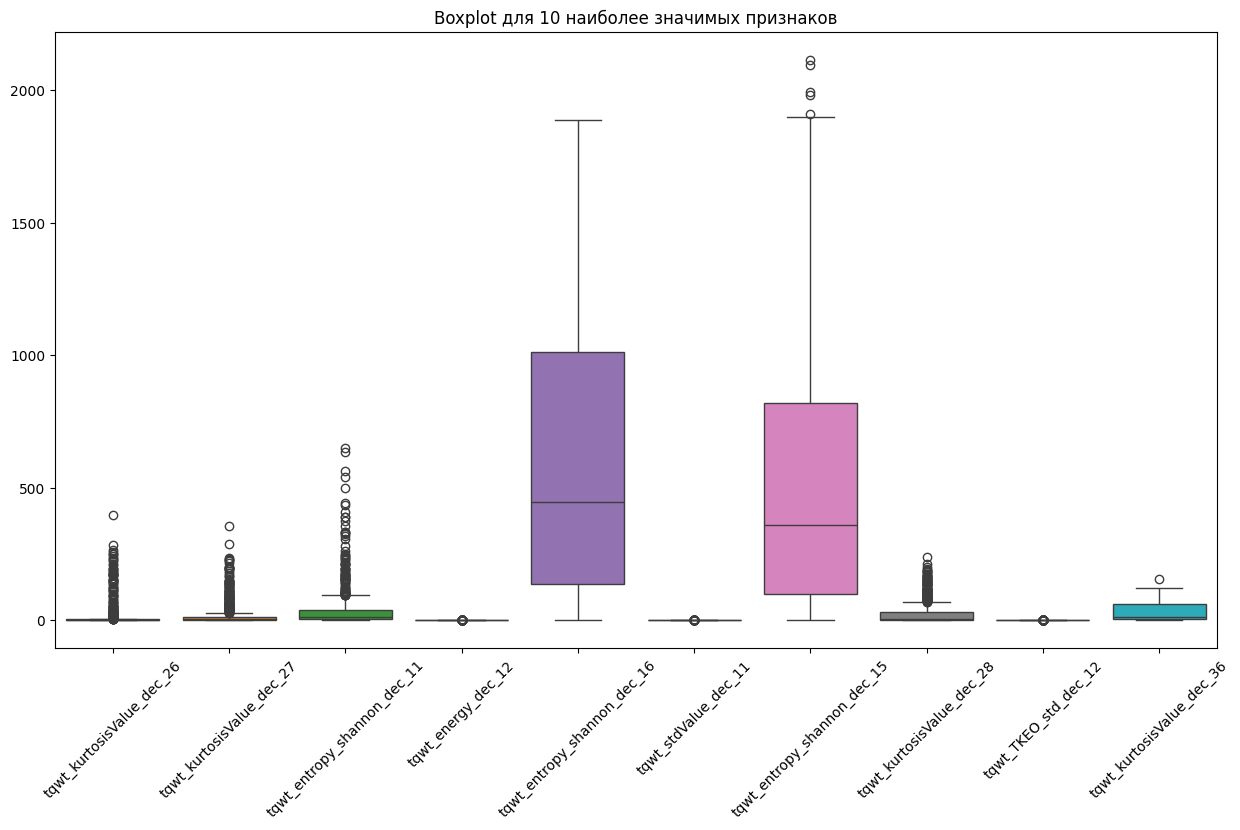

In [16]:
#ВАШ КОД

# Только признаки (без class)
features = df_top.drop('class', axis=1)

# Строим boxplot для всех признаков
plt.figure(figsize=(15, 8))
sns.boxplot(data=features)

plt.xticks(rotation=45)
plt.title("Boxplot для 10 наиболее значимых признаков")
plt.show()

Выводы по полученным графикам: На графике видно, что большинство признаков имеют различный масштаб и значительный разброс значений, а также присутствуют выбросы.


6.2. Построить ***диаграммы распределения*** числовых признаков. Проанализируйте диаграммы и сделайте выводы.

Пример оформления (для одного признака)
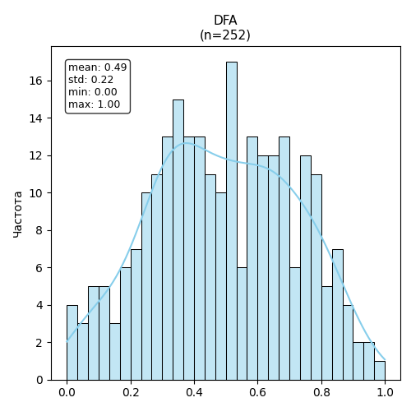


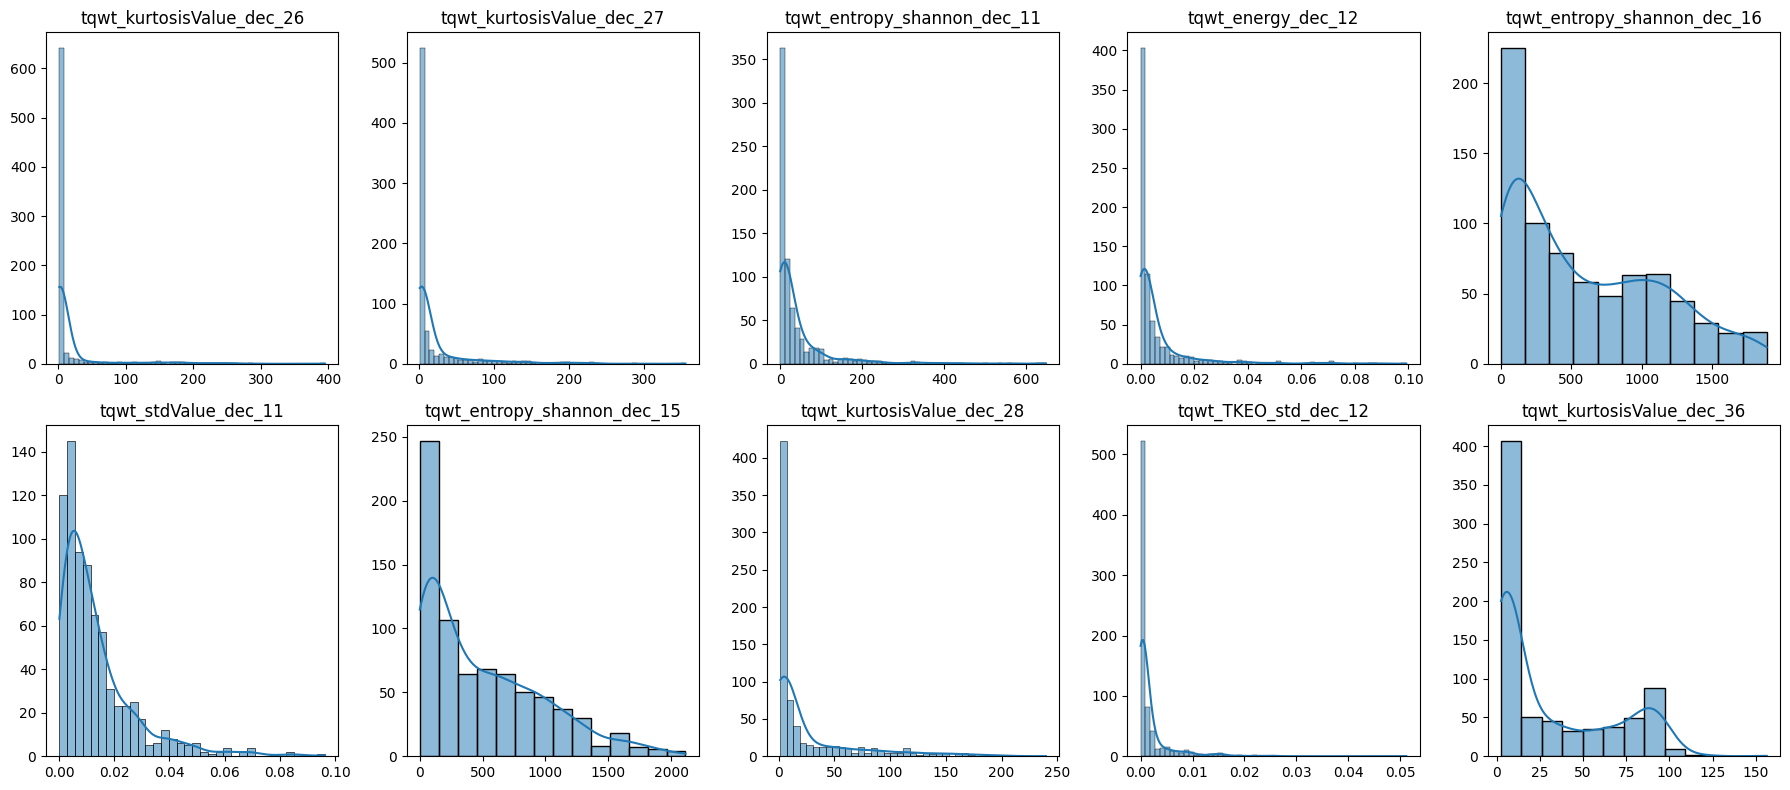

In [17]:
#ВАШ КОД

features = df_top.drop('class', axis=1)

# Создаём сетку графиков (2 строки, 5 столбцов)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

# Строим гистограммы
for i, col in enumerate(features.columns):
    sns.histplot(features[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Выводы по полученным диаграммам: Большинство признаков имеют асимметричное распределение с длинным правым хвостом, что указывает на наличие выбросов и неравномерность данных. Лишь некоторые признаки близки к нормальному распределению, поэтому может потребоваться преобразование или нормализация перед дальнейшим анализом.


6.3. Выполнить ***оценку баланса класса*** с помощью круговой диаграммы распределения результирующего атрибута.

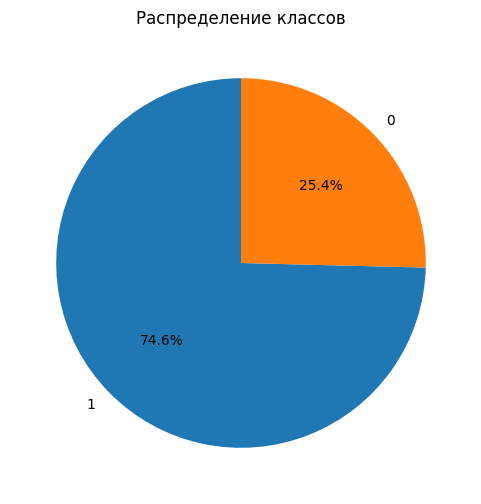

In [18]:
#ВАШ КОД

# Считаем количество классов
class_counts = df['class'].value_counts()

# Строим круговую диаграмму
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение классов')
plt.show()

Сделайте выводы: Наблюдается дисбаланс классов: класс 1 составляет около 74.6%, а класс 0 — около 25.4%. Это может привести к смещению модели в сторону преобладающего класса и потребовать применения методов балансировки данных.